# **Analysis of FDA approved pharmaceuticals**
Summer I 2026 Data Science Project

Ryan Stein, Saif Haider, William Wang, Joseph Sherman

### **Contributions**
**Project idea**:
- Formal Write for P1 Regarding What Dataset (Proposed by Saif) we will use, why we chose it, and what we planned to get out of it (RYAN)

**Dataset Curation and Preprocessing**: Joseph - I imported and loaded the dataset into a dataframe. I also cleaned and parsed the data.

**Data Exploration and Summary Statistics**:
- manufacturer market-concentration analysis (top-10 makers, HHI, single-product-company breakdown) (RYAN)
- William - Conducted the Pearson correlation analysis between warning-section length and dosage administration instruction length, created the scatter plot with a line of best fit, interpreted results, and assisted with proofreading and organizing the final notebook.
- Saif Haider - Conducted data exploration on how drug route relates to warning length and pregnancy/breastfeeding guidance

**ML Algorithm Design/Development**: Joseph - I designed the TF-IDF + KMeans clustering approach to test whether drug warning text aligns with known categories like product type.

**ML Algorithm Training and Test Data Analysis**: Joseph - I vectorized the warning text, used the elbow method to choose k, and evaluated the resulting clusters against product type.
- Saif Haider - Trained Logistic Regression, Decision Tree, and Random Forest models to test whether drug features could predict warning-length category and pregnancy/breastfeeding guidance.

**Visualization, Result Analysis, Conclusion**:
- Created conclusion tying all four of our questions into a single analysis (RYAN)
- Created the cluster-composition visualization (RYAN)
- Created the TF-IDF term visualization (RYAN)
- Saif Haider - Graphed and interpreted the prediction accuracies of the three supervised learning models

**Final Tutorial Report Creation**: 
- Joseph - I added explanatory text and formatting to the overall project.
- Reworded Introduction to align w/ analysis & visualization methods (RYAN)
- William - Proofread and organized final notebook, tested notebook for reproducibility, and prepared the final submission


## **Introduction**

The point of this project is to unveil underlying trends in FDA-approved drugs — who makes them, how they're marketed, and how they're labeled — to make thousands of drug labels easier to interpret. Using the openFDA Drug Label dataset, we explore four primary questions:

1. How concentrated is the drug-label market — is it controlled by a few big players, or partitioned among numerous smaller ones?
2. How does a drug's route of administration relate to its warnings and to whether it's flagged as safe or unsafe during pregnancy and breastfeeding?
3. Do drugs with longer warning sections also have longer dosage and administration instructions?
4. Can the language of a drug's warnings alone reveal its product category (e.g. OTC vs. prescription)?   

### Tools
The following tools should be imported:

- Pandas
- NumPy
- Requests
- MatPlotLib

In [ ]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans



## Data Curation

**Source.** Our data comes from the [openFDA Drug Label API](https://api.fda.gov/drug/label.json), which mirrors the FDA's Structured Product Labeling (SPL) submissions for drugs marketed in the United States. Each record corresponds to one drug label and includes fields such as active/inactive ingredients, purpose, warnings, dosage and administration instructions, pregnancy/breastfeeding guidance, route of administration, and manufacturer.

**Collection.** We paginated through the API in batches of 1,000 records (see the cell below, which only needs to be run once) and saved the combined results to `drug.csv` so the rest of the notebook can work from a local file instead of re-querying the API every time.

**Cleaning and transformation.** After loading `drug.csv` into a DataFrame, we:
- Check for and drop fully duplicated rows.
- Select the subset of columns relevant to our questions (ingredients, purpose, warnings, dosage/administration, pregnancy/breastfeeding guidance, route, manufacturer, etc.).
- Lowercase and strip boilerplate/HTML artifacts from free-text fields (e.g. `warnings`, `purpose`, `dosage_and_administration`).
- Fill missing `active_ingredient` values from `spl_product_data_elements` where possible, then drop the now-redundant column.
- Bucket several free-text fields (e.g. `do_not_use`, `openfda.route`, stop-use/ask-a-doctor language) into consistent categories using small helper functions, so they can be grouped and compared later.

The result, `drug_df`, is the cleaned DataFrame used throughout the rest of the analysis.

In [ ]:
#DON'T RUN THIS
import pandas as pd
import requests

all_drugs = []
num = 0

while True:
    drug_data = requests.get(f"https://api.fda.gov/drug/label.json?limit=1000&skip={num}").json()

    if 'results' not in drug_data:
        break

    all_drugs.extend(drug_data['results'])
    num += 1000

drug_df = pd.json_normalize(all_drugs)
drug_df.to_csv('drug.csv', index=False)

In [121]:
# RUN THIS
df = pd.read_csv("drug.csv", low_memory=False)
df

,effective_time,inactive_ingredient,purpose,keep_out_of_reach_of_children,warnings,questions,spl_product_data_elements,version,dosage_and_administration,pregnancy_or_breast_feeding,stop_use,storage_and_handling,do_not_use,package_label_principal_display_panel,indications_and_usage,set_id,id,active_ingredient,openfda.brand_name,openfda.generic_name,openfda.manufacturer_name,openfda.product_ndc,openfda.product_type,openfda.route,openfda.substance_name,openfda.spl_id,openfda.spl_set_id,openfda.package_ndc,openfda.is_original_packager,openfda.upc,openfda.unii,when_using,ask_doctor,openfda.application_number,openfda.rxcui,openfda.nui,openfda.pharm_class_epc,openfda.pharm_class_cs,spl_unclassified_section,description,clinical_pharmacology,clinical_pharmacology_table,pharmacokinetics,microbiology,microbiology_table,clinical_studies,spl_unclassified_section_table,contraindications,precautions,general_precautions,information_for_patients,drug_interactions,carcinogenesis_and_mutagenesis_and_impairment_of_fertility,pregnancy,nonteratogenic_effects,nursing_mothers,pediatric_use,geriatric_use,adverse_reactions,dosage_and_administration_table,how_supplied,recent_major_changes,boxed_warning,dosage_forms_and_strengths,warnings_and_cautions,drug_interactions_table,use_in_specific_populations,overdosage,mechanism_of_action,pharmacodynamics,nonclinical_toxicology,spl_medguide,spl_medguide_table,openfda.original_packager_product_ndc,openfda.pharm_class_moa,recent_major_changes_table,adverse_reactions_table,clinical_studies_table,spl_patient_package_insert,spl_patient_package_insert_table,instructions_for_use,instructions_for_use_table,drug_abuse_and_dependence,drug_and_or_laboratory_test_interactions,how_supplied_table,laboratory_tests,warnings_table,use_in_specific_populations_table,pediatric_use_table,references,teratogenic_effects,animal_pharmacology_and_or_toxicology,openfda.pharm_class_pe,pregnancy_table,labor_and_delivery,controlled_substance,dependence,ask_doctor_or_pharmacist,active_ingredient_table,purpose_table,references_table,pharmacokinetics_table,other_safety_information,user_safety_warnings,drug_abuse_and_dependence_table,dosage_forms_and_strengths_table,description_table,precautions_table,abuse,geriatric_use_table,pharmacodynamics_table,pharmacogenomics,patient_medication_information,warnings_and_cautions_table,safe_handling_warning,route,risks,statement_of_identity,package_label_principal_display_panel_table,inactive_ingredient_table,indications_and_usage_table,animal_pharmacology_and_or_toxicology_table,information_for_patients_table,contraindications_table,nonclinical_toxicology_table,carcinogenesis_and_mutagenesis_and_impairment_of_fertility_table,information_for_owners_or_caregivers,cleaning,environmental_warning,patient_medication_information_table,storage_and_handling_table,components,intended_use_of_the_device,mechanism_of_action_table,general_precautions_table,drug_and_or_laboratory_test_interactions_table,accessories,ask_doctor_table,when_using_table,ask_doctor_or_pharmacist_table,do_not_use_table,questions_table,disposal_and_waste_handling,veterinary_indications,stop_use_table,abuse_table,overdosage_table,statement_of_identity_table,keep_out_of_reach_of_children_table,boxed_warning_table,health_claim,alarms,laboratory_tests_table,health_care_provider_letter,summary_of_safety_and_effectiveness,health_care_provider_letter_table,guaranteed_analysis_of_feed,troubleshooting,nonteratogenic_effects_table,safe_handling_warning_table,nursing_mothers_table,spl_indexing_data_elements,teratogenic_effects_table,health_claim_table,spl_indexing_data_elements_table
0,20210902,['INACTIVE INGREDIENTS Sucrose'],"['USES USES: Temporary Relief - Acne, Boils* *...",['Keep this and all medication out of reach of...,['WARNINGS This product is to be used for self...,['QUESTIONS OR COMMENTS www.Rxhomeo.com | 1.88...,['SILICEA SILICEA SUCROSE SILICON DIOXIDE SILI...,2,"['DOSAGE Adults- Take 4 or 6 Pellets by mouth,...","['As with any drug, if you

We check the dataset's dimensions before cleaning it.

In [122]:
df.shape

(12687, 165)

We inspect the available column names.

In [123]:
df.columns

Index(['effective_time', 'inactive_ingredient', 'purpose',
       'keep_out_of_reach_of_children', 'warnings', 'questions',
       'spl_product_data_elements', 'version', 'dosage_and_administration',
       'pregnancy_or_breast_feeding',
       ...
       'health_care_provider_letter_table', 'guaranteed_analysis_of_feed',
       'troubleshooting', 'nonteratogenic_effects_table',
       'safe_handling_warning_table', 'nursing_mothers_table',
       'spl_indexing_data_elements', 'teratogenic_effects_table',
       'health_claim_table', 'spl_indexing_data_elements_table'],
      dtype='object', length=165)

In [124]:
# Dup Check

# All Features Values Shared
print("Full Dups:", df.duplicated().sum())

# UID (doc, product) shared
print("Dup 'id' values:    ", df['id'].duplicated().sum())
print("Dup 'set_id'(product) values:", df['set_id'].duplicated().sum())

# Drop triggered from above
_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f" Pre-Dedup Ct. : {_before} | Post-Dedup Ct. : {len(df)} | (Dropped {_before - len(df)} Dups)")

Full Dups: 0
Dup 'id' values:     0
Dup 'set_id'(product) values: 0
 Pre-Dedup Ct. : 12687 | Post-Dedup Ct. : 12687 | (Dropped 0 Dups)


We narrow the raw dataframe down to the columns relevant to our questions, such as ingredients, purpose, warnings, dosage, pregnancy guidance, route, and manufacturer.

In [125]:
drug_df = df[['inactive_ingredient', 'purpose', 'warnings',
       'spl_product_data_elements', 'dosage_and_administration',
       'pregnancy_or_breast_feeding', 'stop_use', 'storage_and_handling',
       'do_not_use', 'active_ingredient', 'openfda.brand_name',
       'openfda.manufacturer_name', 'openfda.product_type', 'openfda.route',
       'openfda.package_ndc', 'when_using', 'ask_doctor',
       'clinical_studies',
       'adverse_reactions']]

We confirm the number of columns kept after selecting our subset.

In [126]:
drug_df.shape

(12687, 19)

We confirm which columns we kept.

In [127]:
drug_df.columns

Index(['inactive_ingredient', 'purpose', 'warnings',
       'spl_product_data_elements', 'dosage_and_administration',
       'pregnancy_or_breast_feeding', 'stop_use', 'storage_and_handling',
       'do_not_use', 'active_ingredient', 'openfda.brand_name',
       'openfda.manufacturer_name', 'openfda.product_type', 'openfda.route',
       'openfda.package_ndc', 'when_using', 'ask_doctor', 'clinical_studies',
       'adverse_reactions'],
      dtype='object')

We clean the 'inactive_ingredient' column by lowercasing it and stripping boilerplate header words and stray punctuation left over from the API's list-like formatting, such as brackets, quotes, and colons.

In [128]:
drug_df['inactive_ingredient'] = drug_df['inactive_ingredient'].str.lower().str.replace("ingredients", '').str.replace("inactive", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['inactive_ingredient']

/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_66765/1619720799.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_df['inactive_ingredient'] = drug_df['inactive_ingredient'].str.lower().str.replace("ingredients", '').str.replace("inactive", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()


0                                                  sucrose
1        talc, polymethyl methacrylate, vinyl dimethico...
2        pareth 25-9, purified water, sodium hydroxide ...
3                                          sucrose/lactose
4                                                      NaN
                               ...                        
12682                                                  NaN
12683    bacillus coagulans, citric acid, edetate disod...
12684       ingredient light mineral oil, white petrolatum
12685                                                  NaN
12686                                                  NaN
Name: inactive_ingredient, Length: 12687, dtype: object

We clean the 'purpose' column by lowercasing it and stripping the "Uses" header and punctuation so only the actual purpose text remains.

In [129]:
drug_df['purpose'] = drug_df['purpose'].str.lower().str.replace("uses", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['purpose']

/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_66765/2431895778.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_df['purpose'] = drug_df['purpose'].str.lower().str.replace("uses", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()


0        temporary relief - acne, boils* * claims based...
1                                        purpose sunscreen
2                             purpose first aid antiseptic
3                      to relieve the symptoms of itching.
4                                                      NaN
                               ...                        
12682                                                  NaN
12683    purpose temporary relief from vaginal itching,...
12684                         purpose first aid antibiotic
12685                                                  NaN
12686                                                  NaN
Name: purpose, Length: 12687, dtype: object

We clean the 'warnings' column by lowercasing it and stripping the "Warnings" header and punctuation so only the warning text itself remains.

In [130]:
drug_df['warnings'] = drug_df['warnings'].str.lower().str.replace("warnings", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['warnings']

/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_66765/1449303301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_df['warnings'] = drug_df['warnings'].str.lower().str.replace("warnings", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()


0        this product is to be used for self-limiting c...
1                                   for external use only.
2                                    for external use only
3        stop use and ask doctor if symptoms persist/wo...
4        not for injection. ofloxacin ophthalmic soluti...
                               ...                        
12682                                                  NaN
12683    use only as directed for vaginal use only ask ...
12684    for external use only do not use • if you are ...
12685                                                  NaN
12686    cardiovascular thrombotic events clinical tria...
Name: warnings, Length: 12687, dtype: object

We clean the 'spl_product_data_elements' column the same way and then remove repeated words within each entry, since the API sometimes repeats the same phrase multiple times per record.

In [131]:
drug_df['spl_product_data_elements'] = drug_df['spl_product_data_elements'].str.lower().str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['spl_product_data_elements'] = drug_df['spl_product_data_elements'].apply(lambda x: ' '.join(dict.fromkeys(str(x).split())))
drug_df['spl_product_data_elements']

/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_66765/339225787.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_df['spl_product_data_elements'] = drug_df['spl_product_data_elements'].str.lower().str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_66765/339225787.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_df['spl_product_data_elements'] = drug_df['spl_pr

0                          silicea sucrose silicon dioxide
1        chantecaille protection naturelle bronze spf 4...
2        betadine povidone-iodine iodine c12-15 pareth-...
3               mezereum daphne bark sucrose lactose white
4        ofloxacin sodium chloride hydrochloric acid hy...
                               ...                        
12682                                               oxygen
12683    yeast gard advanced berberis vulgaris, borax, ...
12684    triple antibiotic polymyxin b sulfate, bacitra...
12685    niaspan er niacin povidone stearic acid polyet...
12686    naproxen silicon dioxide magnesium stearate po...
Name: spl_product_data_elements, Length: 12687, dtype: object

We clean the 'active_ingredient' column by stripping "Drug Facts" and "Active Ingredients" boilerplate along with parenthetical dosage notes, such as "(in each gram)", so only the ingredient names remain.

In [132]:
drug_df['active_ingredient'] = drug_df['active_ingredient'].str.lower().str.replace("ingredients", '').str.replace("drug facts", '').str.replace("active", '').str.replace("drug fact", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '')
drug_df['active_ingredient'] = drug_df['active_ingredient'].str.replace("in each gram", '').str.replace("(", '').str.replace(")", '').str.strip()
drug_df['active_ingredient']

/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_66765/4127942404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_df['active_ingredient'] = drug_df['active_ingredient'].str.lower().str.replace("ingredients", '').str.replace("drug facts", '').str.replace("active", '').str.replace("drug fact", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '')
/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_66765/4127942404.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

0                    ingredient silicea hpus 2x and higher
1        bronze   titanium dioxide 2 %, ethylhexyl meth...
2                povidone-iodine, 5% 0.5% available iodine
3                                                 mezereum
4                                                      NaN
                               ...                        
12682                                                  NaN
12683    borax 3x hpus collinsonia canadensis 3x hpus b...
12684    ingredient  bacitracin zinc 400 units neomycin...
12685                                                  NaN
12686                                                  NaN
Name: active_ingredient, Length: 12687, dtype: object

Some records only listed the active ingredient inside 'spl_product_data_elements' instead of 'active_ingredient', so we backfill the missing values from that column.

In [133]:
drug_df['active_ingredient'] = drug_df['active_ingredient'].fillna(drug_df['spl_product_data_elements'])

/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_66765/2430981737.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_df['active_ingredient'] = drug_df['active_ingredient'].fillna(drug_df['spl_product_data_elements'])


We spot-check the cleaned active ingredient values and then drop the 'spl_product_data_elements' column, since its useful information has already been merged into 'active_ingredient'.

In [134]:
drug_df['active_ingredient'].value_counts()
drug_df = drug_df.drop(columns = 'spl_product_data_elements')

We clean the 'dosage_and_administration' column by stripping boilerplate headers, such as "Dosage and Administration" and "Directions", along with formatting characters like bullets and quotes.

In [135]:
drug_df['dosage_and_administration'] = drug_df['dosage_and_administration'].str.lower().str.replace("ingredients", '').str.replace("drug facts", '').str.replace("active", '').str.replace("drug fact", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '')
drug_df['dosage_and_administration'] = drug_df['dosage_and_administration'].str.replace('dosage and administration', '').str.replace('directions', '').str.replace('dosage', '').str.replace('•', '').str.replace('"', '').str.strip()
drug_df['dosage_and_administration']

0        adults- take 4 or 6 pellets by mouth, three ti...
1        protection naturelle spf 46 pa+++ powder can b...
2        clean the affected area spray a small amount o...
3        adults dissolve 3 to 5 under the tongue three ...
4        the recommended  regimen for the treatment of ...
                               ...                        
12682                                                  NaN
12683    tamper evident if the foil seal on bottle open...
12684    clean the affected area  apply a small amount ...
12685    2  niaspan should be taken at bedtime, after a...
12686    carefully consider the potential benefits and ...
Name: dosage_and_administration, Length: 12687, dtype: object

We recode the 'pregnancy_or_breast_feeding' column. Since a non-null value in the raw data means a caution or warning was present, we map present values to 'Bad' and missing values to 'Fine'.

In [136]:
drug_df.loc[drug_df['pregnancy_or_breast_feeding'].notna(), 'pregnancy_or_breast_feeding'] = 'Bad'
drug_df['pregnancy_or_breast_feeding'] = drug_df['pregnancy_or_breast_feeding'].fillna('Fine')
drug_df['pregnancy_or_breast_feeding']

0         Bad
1        Fine
2        Fine
3        Fine
4        Fine
         ... 
12682    Fine
12683     Bad
12684    Fine
12685    Fine
12686    Fine
Name: pregnancy_or_breast_feeding, Length: 12687, dtype: object

We bucket the free-text 'stop_use' reasons into a small set of consistent categories, such as rash, allergic reaction, and irritation, so they can be grouped and compared later.

In [137]:
def categorize_stop_use(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if 'rash' in text:
        return 'rash'
    elif 'allergic' in text:
        return 'allergic reaction'
    elif 'irritat' in text:
        return 'irritation'
    elif 'rectal bleeding' in text or 'bowel' in text:
        return 'rectal bleeding or bowel movement problems'
    elif 'dry' in text:
        return 'dry'
    elif 'days' in text or 'week' in text or 'persist' in text or 'improve' in text or 'regular' in text:
        return 'symptoms persist after some time'
    elif 'do not use' in text:
        return np.nan
    else:
        return 'other'

drug_df['stop_use'] = drug_df['stop_use'].apply(lambda x: categorize_stop_use(x))
drug_df['stop_use'].value_counts()

stop_use
rash                                          1626
symptoms persist after some time              1216
irritation                                     881
allergic reaction                              289
rectal bleeding or bowel movement problems     176
other                                          125
dry                                              3
Name: count, dtype: int64

We clean the 'storage_and_handling' column by stripping boilerplate headers and punctuation, along with the "Other Information" section label that sometimes prefixes this field.

In [138]:
drug_df['storage_and_handling'] = drug_df['storage_and_handling'].str.lower().str.replace("ingredients", '').str.replace("drug facts", '').str.replace("active", '').str.replace("drug fact", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '')
drug_df['storage_and_handling'] = drug_df['storage_and_handling'].str.replace('other information', '')
drug_df['storage_and_handling']

0                       storage store in a cool dark place
1                                                      NaN
2         store at 25⁰c (77⁰f); excursions permitted be...
3                                                      NaN
4                                                      NaN
                               ...                        
12682                                                  NaN
12683                                                  NaN
12684                                                  NaN
12685                                                  NaN
12686                                                  NaN
Name: storage_and_handling, Length: 12687, dtype: object

We clean the 'do_not_use' column by stripping the "Do Not Use" header and punctuation. Since drugs with no do_not_use text are generally OK to use, we fill missing values with 'use'.

In [139]:
drug_df['do_not_use'] = drug_df['do_not_use'].str.lower().str.replace('do not use', '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['do_not_use'] = drug_df['do_not_use'].fillna('use')
drug_df['do_not_use']

0        if capseal is broken or missing. close the cap...
1                                                      use
2        in the eyes over large areas of the body if yo...
3                                                      use
4                                                      use
                               ...                        
12682                                                  use
12683    if you have never had a vaginal yeast infectio...
12684                                                  use
12685                                                  use
12686                                                  use
Name: do_not_use, Length: 12687, dtype: object

We clean the 'openfda.brand_name' column and rename it to 'brand_name'.

In [140]:
drug_df['openfda.brand_name'] = drug_df['openfda.brand_name'].str.lower().str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['brand_name'] = drug_df['openfda.brand_name']
drug_df = drug_df.drop(columns = ['openfda.brand_name'])
drug_df['brand_name']

0                    silicea
1                        NaN
2                   betadine
3                        NaN
4                        NaN
                ...         
12682                    NaN
12683    yeast gard advanced
12684      triple antibiotic
12685                    NaN
12686                    NaN
Name: brand_name, Length: 12687, dtype: object

We clean manufacturer names by dropping legal suffixes like LLC, Inc, Co, and Ltd along with punctuation, so the same company isn't split across multiple spellings, and then rename 'openfda.manufacturer_name' to 'manufacturer_name'.

In [141]:
drug_df['openfda.manufacturer_name'] = drug_df['openfda.manufacturer_name'].str.lower().str.replace(".", '').str.replace("llc", '').str.replace(",", '').str.replace("inc", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['openfda.manufacturer_name'] = drug_df['openfda.manufacturer_name'].str.replace("co", '').str.replace("ltd", '')
drug_df['manufacturer_name'] = drug_df['openfda.manufacturer_name']
drug_df = drug_df.drop(columns = ['openfda.manufacturer_name'])
drug_df['manufacturer_name']

0        rxhomeo private limited dba rxhomeo
1                                        NaN
2                 atlantis nsumer healthcare
3                                        NaN
4                                        NaN
                        ...                 
12682                                    NaN
12683                wisnsin pharmacal mpany
12684                 nucare pharmaceuticals
12685                                    NaN
12686                                    NaN
Name: manufacturer_name, Length: 12687, dtype: object

We bucket the 'openfda.product_type' column into OTC, prescription, or cellular therapy categories, and then drop the raw column now that 'product_type' replaces it.

In [142]:
def categorize_product_type(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if 'otc' in text:
        return 'OTC'
    elif 'prescription' in text:
        return 'prescription'
    elif 'cellular therapy' in text:
        return 'cellular therapy'

drug_df['product_type'] = drug_df['openfda.product_type'].apply(lambda x: categorize_product_type(x))
drug_df = drug_df.drop(columns = ['openfda.product_type'])
drug_df['product_type']

0        OTC
1        NaN
2        OTC
3        NaN
4        NaN
        ... 
12682    NaN
12683    OTC
12684    OTC
12685    NaN
12686    NaN
Name: product_type, Length: 12687, dtype: object

We clean the 'openfda.route' column and rename it to 'route'.

In [143]:
drug_df['openfda.route'] = drug_df['openfda.route'].str.lower().str.replace(".", '').str.replace("llc", '').str.replace(",", '').str.replace("inc", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['route'] = drug_df['openfda.route']
drug_df = drug_df.drop(columns = ['openfda.route'])
drug_df['route']

0           oral
1            NaN
2        topical
3            NaN
4            NaN
          ...   
12682        NaN
12683    vaginal
12684    topical
12685        NaN
12686        NaN
Name: route, Length: 12687, dtype: object

We bucket the free-text 'when_using' warnings into a small set of consistent categories, such as eye contact, alcohol, dosage limits, and food or milk.

In [144]:
def categorize_when_using(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if 'eyes' in text:
        return 'keep out of eyes'
    elif 'alcohol' in text:
        return 'avoid alcoholic beverages'
    elif 'caffine' in text:
        return 'avoid caffine'
    elif 'more than' in text or 'dosage' in text or 'dose' in text:
        return 'do not take more than directed'
    elif 'food or milk' in text:
        return 'take with food or milk if stomach upset'
    else:
        return 'other'

drug_df['when_using'] = drug_df['when_using'].apply(lambda x: categorize_when_using(x))
drug_df['when_using'].value_counts()

when_using
keep out of eyes                           2154
other                                       542
do not take more than directed              511
avoid alcoholic beverages                   396
take with food or milk if stomach upset      90
Name: count, dtype: int64

We bucket the free-text 'ask_doctor' guidance into a small set of consistent categories, such as liver or kidney disease and breathing issues.

In [145]:
def categorize_ask_doctor(text):
    if pd.isna(text) or text == "['']":
        return np.nan
    text = text.lower()
    if 'liver' in text and 'kidney' in text:
        return 'if you have liver or kidney disease'
    elif 'liver' in text and not 'kidney' in text:
        return 'if you have liver disease'
    elif 'kidney' in text and not 'liver' in text:
        return 'if you have kidney disease'
    elif 'breathing' in text:
        return 'if you have breathing issues'
    elif 'fever mucus' in text:
        return 'if you have fever mucus in stool'
    else:
        return 'other'

drug_df['ask_doctor'] = drug_df['ask_doctor'].apply(lambda x: categorize_ask_doctor(x))
drug_df['ask_doctor'].value_counts()

ask_doctor
other                                  1160
if you have liver disease               448
if you have liver or kidney disease     382
if you have breathing issues            202
if you have kidney disease              177
if you have fever mucus in stool         28
Name: count, dtype: int64

We clean the 'clinical_studies' column by stripping section-number artifacts like "14" and header words left over from the SPL section title, then lowercase it and strip punctuation.

In [146]:
drug_df['clinical_studies'] = drug_df['clinical_studies'].str.replace('14', '').str.replace('CLINICAL', '').str.replace('TRIALS', '').str.replace('STUDIES', '').str.lower().str.replace(".", '').str.replace(",", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['clinical_studies']

0                                                      NaN
1                                                      NaN
2                                                      NaN
3                                                      NaN
4        clinical studies conjunctivitis in a randomize...
                               ...                        
12682                                                  NaN
12683                                                  NaN
12684                                                  NaN
12685    1 niacin clinical studies the role of ldl-c in...
12686    general information naproxen has been studied ...
Name: clinical_studies, Length: 12687, dtype: object

We clean the 'adverse_reactions' column by stripping section-number artifacts like "6" and header words left over from the SPL section title, then lowercase it and strip punctuation.

In [147]:
drug_df['adverse_reactions'] = drug_df['adverse_reactions'].str.replace('ADVERSE', '').str.replace('REACTIONS', '').str.replace('6', '').str.lower().str.replace(".", '').str.replace(",", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['adverse_reactions']

0                                                      NaN
1                                                      NaN
2                                                      NaN
3                                                      NaN
4        ophthalmic use the most frequently reported dr...
                               ...                        
12682                                                  NaN
12683                                                  NaN
12684                                                  NaN
12685    because clinical studies are conducted under w...
12686    the following adverse reactions are discussed ...
Name: adverse_reactions, Length: 12687, dtype: object

## Exploratory Data Analysis

With `drug_df` cleaned, each team member explores a different question using the dataset. Each sub-section below states the question, the approach, the resulting plot(s), and a short summary of findings.

### Analysis 1 — Manufacturer Market Concentration (Ryan Stein)

**Question:** Is the drug-label market ruled by a few giant manufacturers (concentrated), or split among many small players (fragmented)?

**Approach:** We quantify:
- The top 10 biggest drug makers and what % of total labeled share they account for.
- How many manufacturers are "small" (just 1–2 products).
- The Herfindahl-Hirschman Index (HHI) — a standard concentration score.

We take a copy of `drug_df` restricted to drugs with a labeled manufacturer, dropping any drugs without one, and report what percentage of drugs had no manufacturer label.

In [148]:
makers_df = drug_df.copy()

_base_len = len(makers_df)

makers_df = makers_df["manufacturer_name"].dropna()

_post_len = len(makers_df)

print(f"Total Drugs : {_base_len} | Labeled Drugs : {_post_len} | Unlabeled % : {((_base_len - _post_len) / _base_len) * 100}%")

Total Drugs : 12687 | Labeled Drugs : 4821 | Unlabeled % : 62.000472925041386%


We count how many drugs each manufacturer produces.

In [149]:
cts = makers_df.value_counts()

cts.head()

manufacturer_name
bryant ranch prepack        226
a-s medication solutions    151
hahnemann laboratories       78
remedyrepack                 70
proficient rx lp             68
Name: count, dtype: int64

We compute each manufacturer's share of the market as a percentage, and summarize the combined share held by the top 1, top 5, and top 10 manufacturers.

In [150]:
shares = makers_df.value_counts(normalize=True) * 100

_t1 = shares.iloc[0]
_t5 = shares.head(5).sum()
_t10 = shares.head(10).sum()

print(f"Top Manufacturer Market Share : {_t1}% | Top 5 Manufacturers\' Market Share : {_t5}% | Top 10 Manufacturers\' Market Share : {_t10}%")


Top Manufacturer Market Share : 4.687824102883219% | Top 5 Manufacturers' Market Share : 12.300352623936943% | Top 10 Manufacturers' Market Share : 17.9215930304916%


We count how many manufacturers make only a single product. Interestingly, almost half of all manufacturers turn out to be single-product companies. We then bin manufacturers into size ranges (1, 2-3, 4-10, 11-50, 50+) based on how many products they make.

In [151]:
solo_ct = (cts <= 1).sum()
solo_pct = (solo_ct / cts.shape[0]) * 100

print(f"Manufacturers With 1 Product : {solo_ct}x | {solo_pct}%")

_ul = 10**9
buckets = pd.cut(cts, bins=[0,1,3,10,50,_ul],labels=["1","2-3","4-10","11-50","50+"])
buckets.value_counts().sort_index()

Manufacturers With 1 Product : 597x | 51.958224543080945%


count
1        597
2-3      275
4-10     184
11-50     85
50+        8
Name: count, dtype: int64

We compute the Herfindahl-Hirschman Index (HHI), a standard measure of market concentration, and translate it into an equivalent number of equal-sized competitors.

In [152]:
hhi = (shares ** 2).sum()
print(f" HHI: {hhi}")

_max_score = 10_000
eq_size_hypo = _max_score / hhi
print(f" Market Behaves like {eq_size_hypo} Competitors -- No One Really Dominates")

 HHI: 64.64191333282649
 Market Behaves like 154.69839125138944 Competitors -- No One Really Dominates


**Interpretation.** HHI is a standard measure of market concentration — whether one big player dominates or many small players split the market evenly. The score is based on squared percentage shares:

| Player(s) | Percent Share | Score |
|---|---|---|
| 1 | 100 | 10,000 |
| 2 | 50 | 2,500 |
| ... | ... | ... |
| 1000s | ~0 | 0 |

We're on the very low end of the spectrum, where no one really has a grip on the market.

In [153]:
_t10 = cts.head(10).index
mix = pd.crosstab(drug_df["manufacturer_name"],
                  drug_df["product_type"]).loc[_t10]
mix

product_type,OTC,cellular therapy,prescription
manufacturer_name,,,
bryant ranch prepack,5,0,221
a-s medication solutions,14,0,137
hahnemann laboratories,78,0,0
remedyrepack,0,0,70
proficient rx lp,4,0,64
nucare pharmaceuticals,5,0,56
preferred pharmaceuticals,11,0,48
nop d/b/a/ unilever,52,0,0
pd-rx pharmaceuticals,3,0,47


We visualize the top 10 manufacturers by product count as a horizontal bar chart, labeling each bar with its exact count.

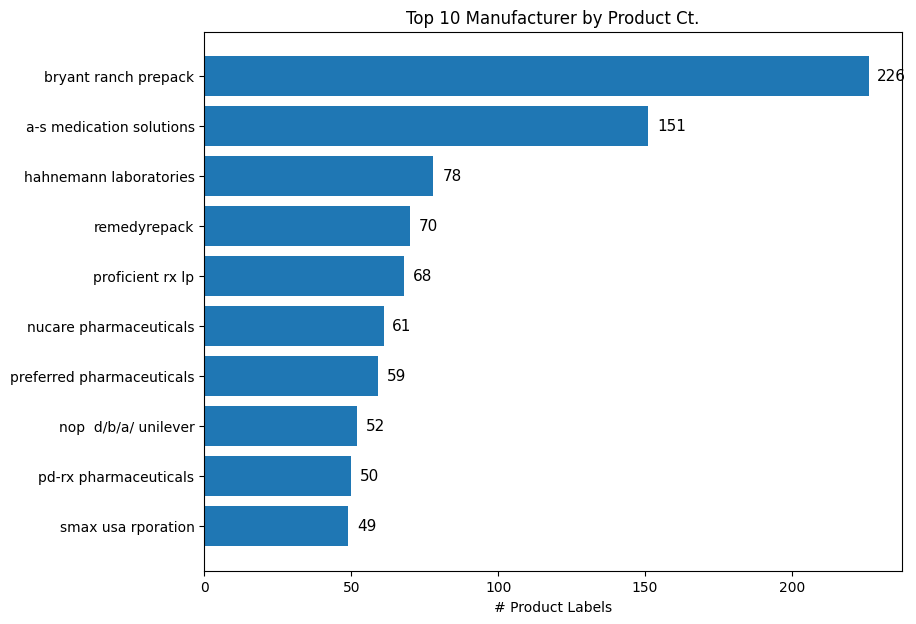

In [154]:
_t10 = cts.head(10).sort_values()

fig, ax = plt.subplots(figsize=(9,7))
ax.barh(_t10.index, _t10.values)
ax.set_xlabel("# Product Labels")
ax.set_title("Top 10 Manufacturer by Product Ct.")

for i, v in enumerate(_t10.values):
    ax.text(v + 3, i, str(v), va="center", fontsize=11)

plt.show()

**Observation.** The #1 and #2 manufacturers aren't actually that much bigger than the rest, and the makers ranked 8th through 10th are nearly identical in size — this supports the hypothesis that there isn't a single dominant player with a clear edge in market share.

We also plot the product counts for the top 20 manufacturers alongside their cumulative share of the total market.

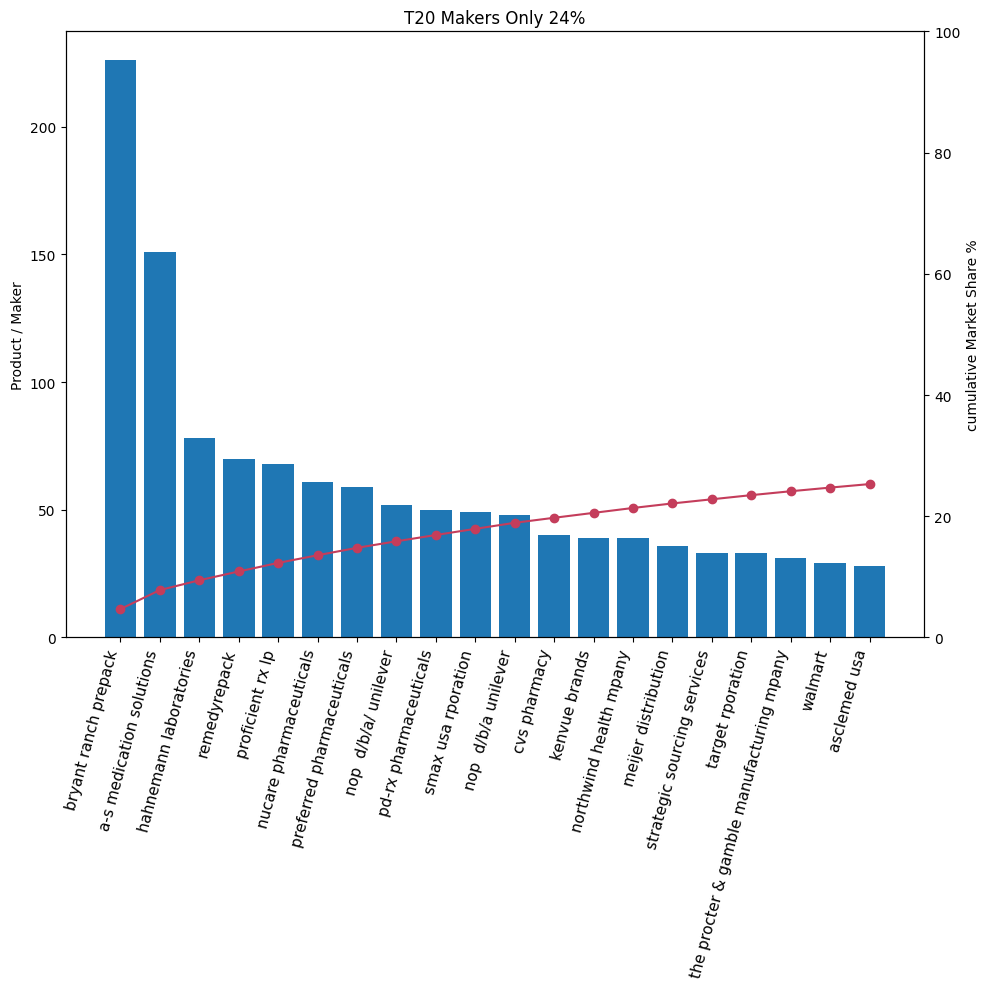

In [155]:
_t20 = cts.head(20)
cum_percent = (_t20.cumsum() / len(makers_df)) * 100

fig, ax = plt.subplots(figsize=(10, 10))

ax.bar(range(len(_t20)), _t20.values)
ax.set_ylabel("Product / Maker")
ax.set_xticks(range(len(_t20)))
ax.set_xticklabels(_t20.index, rotation=75, ha="right", fontsize=11)

ax2 = ax.twinx()
ax2.plot(range(len(_t20)), cum_percent.values, color="#c43d5b", marker="o")
ax2.set_ylabel("cumulative Market Share %")
ax2.set_ylim(0, 100)

ax.set_title("T20 Makers Only 24%")
plt.tight_layout(); plt.show()

**Observation.** Even combined, the top 20 manufacturers don't account for a quarter of the market.

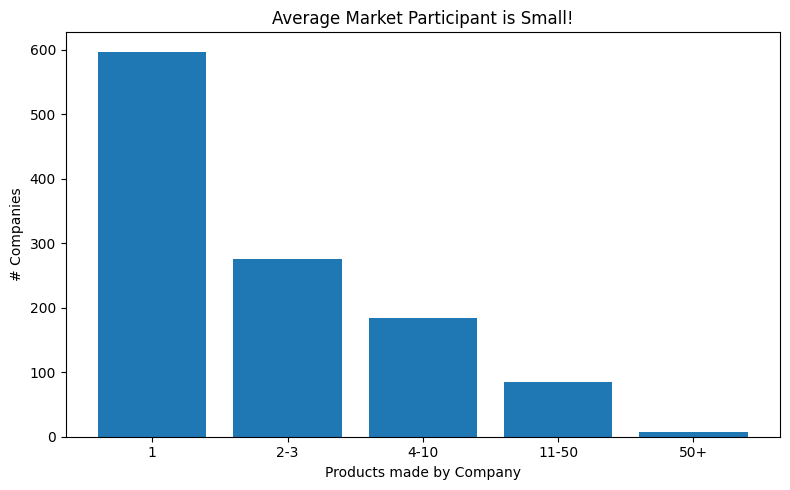

In [156]:
order = ["1","2-3","4-10","11-50","50+"]
band = buckets.value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(band.index, band.values)
ax.set_xlabel("Products made by Company")
ax.set_ylabel("# Companies")
ax.set_title("Average Market Participant is Small!")
plt.tight_layout(); plt.show()

**Summary.** This market is not ruled by a few giants, but instead split amongst a mass of small 1–2 product companies, plus a few bigger players with their own caveats. Our key evidence:

1. The top maker accounts for only ~4.5% of labels.
2. The top 20 makers combined still don't hit a quarter of the market (24%).
3. The HHI of ~59 is at the very bottom of the concentration scale (recall 10,000 = monopoly), equivalent to ~170 equal-sized makers splitting the pie — no one really has a grip.

**Caveat:** the "biggest" names among the top makers aren't even real brands — they're repackagers (Bryant Ranch Prepack, A-S Medication Solutions, Proficient Rx, RemedyRepack, NuCare, etc.). They just re-bottle existing drugs, which racks up a lot of labels without them actually producing anything.

### Analysis 2 — Drug Route vs. Warnings & Pregnancy Safety (Saif)

**Question:** How does the route through which a drug is administered relate to other features of the data? Specifically:

1. How is the count of drugs distributed across the different routes?
2. How does drug route relate to warnings?
3. How does drug route relate to whether the drug is safe for pregnancy or breastfeeding?

Since our main focus is on drug route, we drop any drug that does not have a route filled out. To draw conclusions on routes that have a decent amount of data, we only look at routes that have at least 100 medications associated with them.

In [157]:
route_df = drug_df.copy()

# Preserve an unfiltered copy for the supervised learning analysis
drug_df2 = drug_df.copy()
route_df = route_df[route_df["route"].notna()]
common_routes = route_df["route"].value_counts()
print("Count of drugs before drop")
count_before = common_routes.sum()
print(count_before)
common_routes = common_routes[common_routes >= 100]
print("Count of drugs after drop")
count_after = common_routes.sum()
print(count_after)
print("Percentage of medication not discarded due to uncommon routes")
print(str(((count_after/count_before)) * 100) + "%")
display(common_routes)

# [hoisted] define important_routes here so the pregnancy cell below can use it
important_routes = pd.Series(common_routes.index)


Count of drugs before drop
4739
Count of drugs after drop
4226
Percentage of medication not discarded due to uncommon routes
89.17493142013083%


route
oral           2496
topical        1575
intravenous     155
Name: count, dtype: int64

First, we observe the mean, median, and standard deviation of how many drugs use each route. Since the disparity between the mean and median implies skewness, and the standard deviation is high, we also run a skew test to check for strong skew toward the most common routes.

Mean 1408.6666666666667
Median 1575.0
Standard deviation 1179.330459766614
Skew test result: -0.6220567949743947


<Axes: title={'center': 'Number of drugs for each route'}, xlabel='Route', ylabel='# Of Drugs'>

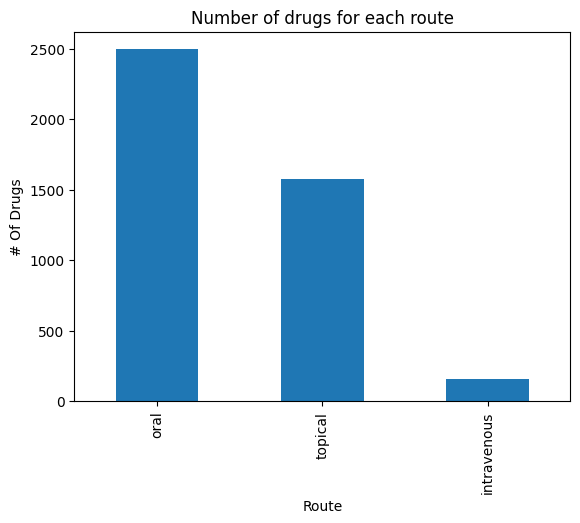

In [158]:
mean = count_after/(len(common_routes))
median = common_routes.median()
std = common_routes.std()
print("Mean " + str(mean))
print("Median " + str(median))
print("Standard deviation " + str(std))
print("Skew test result: " + str(common_routes.skew()))
common_routes.plot(kind = "bar", xlabel = "Route", ylabel = "# Of Drugs", title = "Number of drugs for each route")

The skew result of about 1.3 implies a strong right skew. Since `common_routes` was already sorted, this tells us the gap between the routes with the most drugs and the rest is extremely high, consistent with our mean, median, and standard deviation calculations. This bar graph confirms that most drugs belong to just two of the six route categories.

We check how pregnancy and breastfeeding safety varies by route, for the routes we're focusing on.

Amount of null values for both:
route                          0
pregnancy_or_breast_feeding    0
dtype: int64


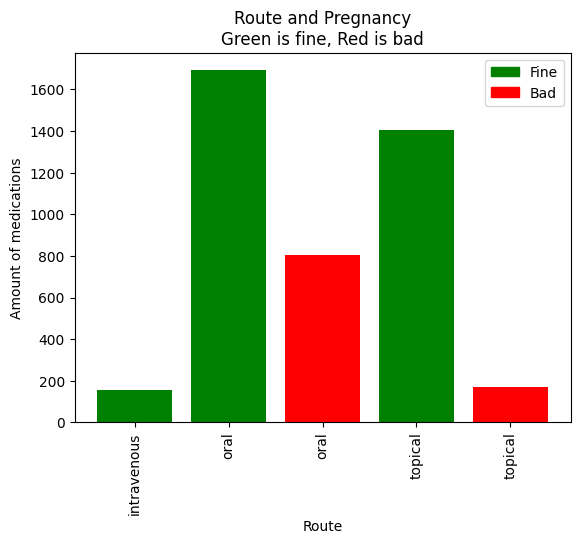

In [159]:
preg_df = route_df.copy()
preg_df = preg_df[["route", "pregnancy_or_breast_feeding"]]
print("Amount of null values for both:")
print(preg_df.isna().sum())
preg_df = preg_df[preg_df["route"].isin(important_routes)]
preg_count_df = preg_df.value_counts()
preg_count_df = preg_count_df.reset_index()
preg_count_df["route"] = preg_count_df["route"].astype(str)
preg_count_df["pregnancy_or_breast_feeding"] = preg_count_df["pregnancy_or_breast_feeding"].astype(str)
preg_count_df = preg_count_df.set_index("route")
preg_count_df = preg_count_df.sort_index()
preg_count_df = preg_count_df.reset_index()
colors = []
preg_count_df["route"] = preg_count_df["route"].astype(str)
fine_or_not = preg_count_df['pregnancy_or_breast_feeding']
for checker in fine_or_not:
  if (checker == "Fine"):
    colors.append("green")
  elif (checker == "Bad"):
    colors.append("red")
plt.bar(preg_count_df.index, preg_count_df["count"], color = colors)
plt.xlabel("Route")
plt.ylabel("Amount of medications")
plt.xticks(preg_count_df.index, preg_count_df["route"], rotation = 90)
plt.title("Route and Pregnancy\nGreen is fine, Red is bad")

import matplotlib.patches as mpatches
plt.legend(handles=[mpatches.Patch(color="green", label="Fine"), mpatches.Patch(color="red", label="Bad")])

plt.show()

**Conclusion for this portion.** Most drug routes are safe for pregnancy and breastfeeding. Oral and topical routes pose the most risk.

To determine how routes relate to warnings, we use two metrics: the average character length of all warnings for each route, and the average number of sentences in the warnings for each route. We use both approaches because the data isn't formatted consistently, which helps minimize our margin of error.

<Axes: title={'center': 'Routes and warnings relation'}, xlabel='Route', ylabel='Average length of Warn'>

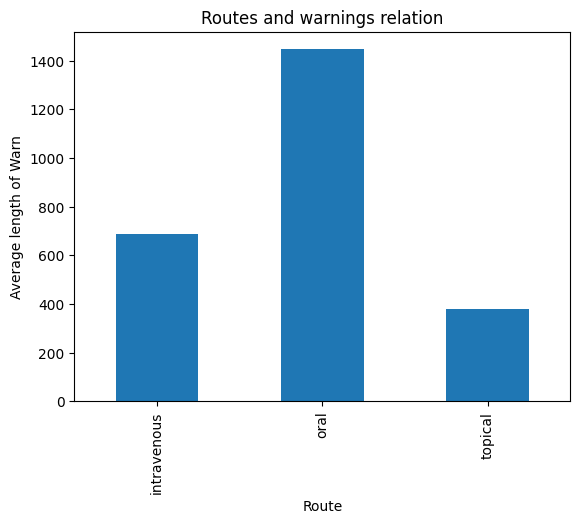

In [160]:
warnings_df = route_df.copy()
warnings_df = warnings_df[["route", "warnings"]]
important_routes = pd.Series(common_routes.index)
warnings_df = warnings_df[warnings_df["route"].isin(important_routes)]
warnings_df["warnings_length"] = warnings_df["warnings"].str.len()
warnings_df["warnings_length"] = warnings_df["warnings_length"].fillna(0)
warning_avgs = warnings_df.groupby("route")["warnings_length"].mean()
warning_meds = warnings_df.groupby("route")["warnings_length"].median()
display(warning_avgs.plot(kind = "bar", xlabel = "Route", ylabel = "Average length of Warn", title = "Routes and warnings relation"))

<Axes: title={'center': 'Routes and warnings relation'}, xlabel='Route', ylabel='Median length of Warn'>

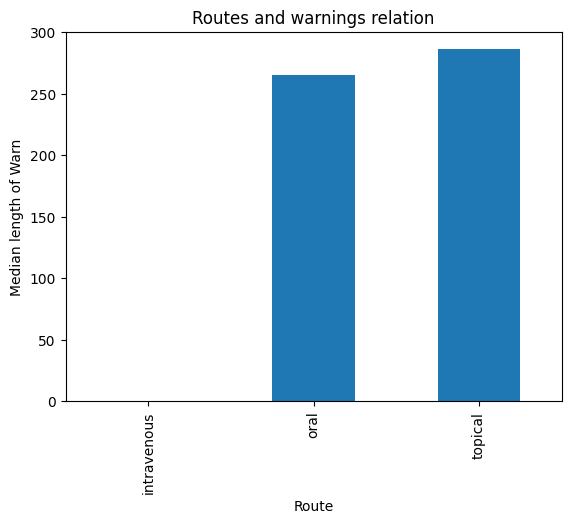

In [161]:
display(warning_meds.plot(kind = "bar", xlabel = "Route", ylabel = "Median length of Warn", title = "Routes and warnings relation"))

The mean and median graphs differ quite a bit, implying that for many routes, a few drugs are skewing up the average warning length. Oral drugs have the most warnings in both plots. Intravenous and respiratory routes have a median warning length of 0, but intravenous has the second-highest average, which could imply that most intravenous drugs are safe but a few carry many warnings. Next, we repeat this analysis using sentence count instead of character length as a second warning-severity metric.

<Axes: title={'center': 'Routes and warnings relation Sentence Check'}, xlabel='Route', ylabel='Average length of Warn'>

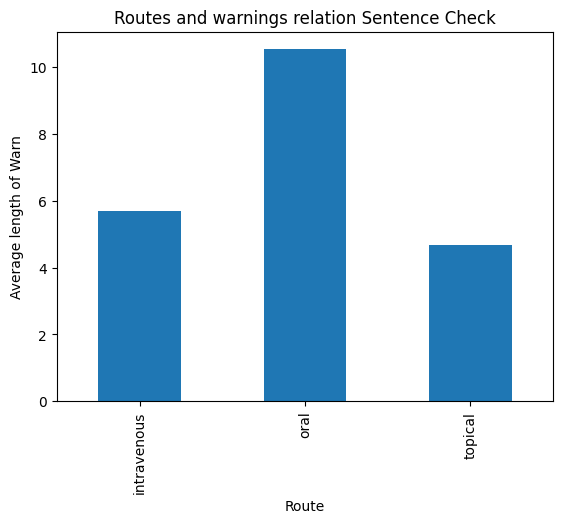

In [162]:
def check_sentences(a_warning):
  if(pd.isna(a_warning)):
    return 0
  a_warning = str(a_warning)
  if(a_warning.count(".") == 0):
    return 1
  else:
    return a_warning.count(".")
warnings_df["warning_sentences"] = warnings_df["warnings"].apply(check_sentences)
warning_avgs_sent = warnings_df.groupby("route")["warning_sentences"].mean()
warning_meds_sent = warnings_df.groupby("route")["warning_sentences"].median()
display(warning_avgs_sent.plot(kind = "bar", xlabel = "Route", ylabel = "Average length of Warn", title = "Routes and warnings relation Sentence Check"))

<Axes: title={'center': 'Routes and warnings relation Sentence Check'}, xlabel='Route', ylabel='Median length of Warn'>

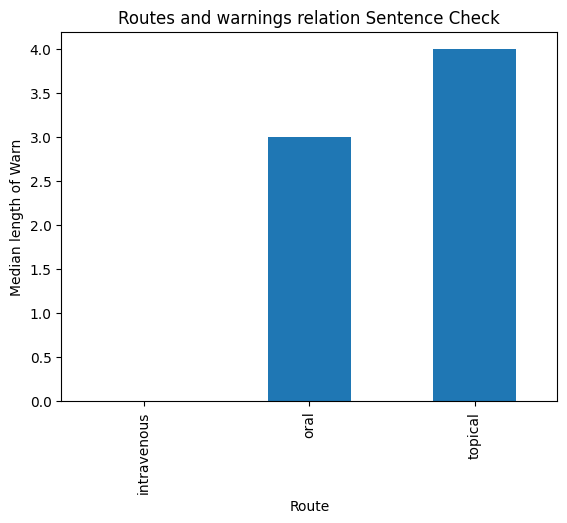

In [163]:
display(warning_meds_sent.plot(kind = "bar", xlabel = "Route", ylabel = "Median length of Warn", title = "Routes and warnings relation Sentence Check"))

A fairly consistent pattern emerges: oral drugs have the most warnings associated with them, with the median-sentence-length graph being the only exception. The two methods we used to gauge warning severity by route — character length and sentence count — are fairly consistent between their means and medians.

**Summary of Conclusions:**

1. A vast majority of drugs belong to 2 categories: oral or topical.
2. Based on most methods of evaluation, oral drugs have the most warnings associated with them. While respiratory and intravenous drugs have the least warnings by median, their averages are much higher, implying a subset of drugs using those routes have quite a high number of warnings.
3. The majority of drugs for each route are safe for pregnant/breastfeeding women.

### Analysis 3 — Warning vs. Dosage Length Correlation (William)

**Question:** Is there a correlation between the length of a drug's warning section and the length of its dosage and administration instructions?

**Approach:** Determine whether drugs with longer warning sections also tend to have longer dosage instructions, by computing the Pearson correlation coefficient and making a scatter plot with a line of best fit to visualize the relationship.

We convert the text for warnings and dosage instructions into character-length values, then preview the first few rows.

In [164]:
corr_df = drug_df.copy()

corr_df["warning_length"] = (corr_df["warnings"].fillna("").str.len())
corr_df["dosage_length"] = (corr_df["dosage_and_administration"].fillna("").str.len())

corr_df[["warning_length", "dosage_length"]].head()

,warning_length,dosage_length
0,406,138
1,22,224
2,21,155
3,114,289
4,973,624


We summarize descriptive statistics for the warning and dosage length columns.

In [165]:
corr_df[["warning_length", "dosage_length"]].describe()

,warning_length,dosage_length
count,12687.000000,12687.000000
mean,1163.435879,1580.180815
std,2781.047744,2895.673742
min,0.000000,0.000000
25%,21.000000,151.000000
50%,286.000000,358.000000
75%,814.500000,1555.500000
max,45059.000000,31572.000000


We calculate the Pearson correlation coefficient between warning length and dosage length.

In [166]:
correlation = corr_df["warning_length"].corr(corr_df["dosage_length"])

print(f"Pearson Correlation Coefficient: {correlation:.3f}")

Pearson Correlation Coefficient: 0.249


A Pearson correlation coefficient of 0.244 means there is a weak positive correlation, suggesting that drugs with longer warning sections tend to have longer dosage and administration instructions, though the relationship is not strong.

To better visualize the relationship between the two variables, we remove extreme outliers and entries missing either warning or dosage/administration text. (The correlation coefficient above was calculated using the complete dataset.)

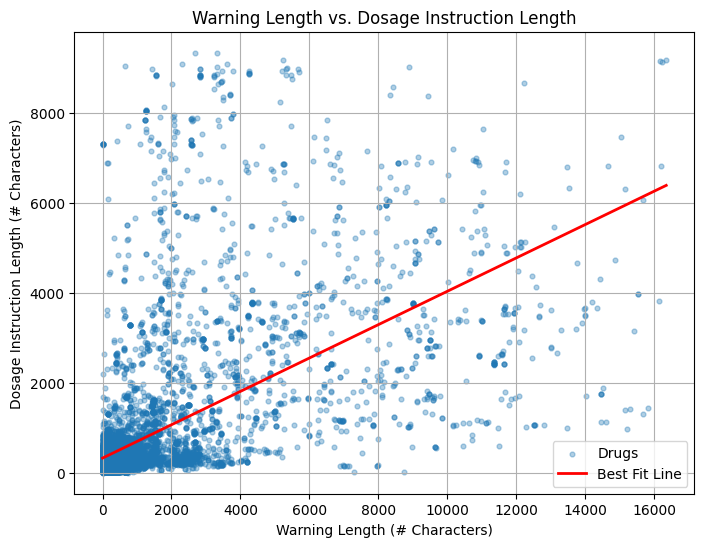

In [167]:
plot_df = corr_df[
    (corr_df["warning_length"] > 0) &
    (corr_df["dosage_length"] > 0)
]

plot_df = plot_df[
    (plot_df["warning_length"] <= plot_df["warning_length"].quantile(0.99)) &
    (plot_df["dosage_length"] <= plot_df["dosage_length"].quantile(0.99))
]

plt.figure(figsize=(8,6))

plt.scatter(
    plot_df["warning_length"],
    plot_df["dosage_length"],
    alpha=0.35,
    s=12,
    label="Drugs"
)

# Line of best fit
m, b = np.polyfit(
    plot_df["warning_length"],
    plot_df["dosage_length"],
    1
)

x = np.linspace(
    plot_df["warning_length"].min(),
    plot_df["warning_length"].max(),
    100
)

plt.plot(
    x,
    m*x + b,
    color="red",
    linewidth=2,
    label="Best Fit Line"
)

plt.title("Warning Length vs. Dosage Instruction Length")
plt.xlabel("Warning Length (# Characters)")
plt.ylabel("Dosage Instruction Length (# Characters)")
plt.grid(True)
plt.legend()

plt.show()

The scatter plot shows a slight upward trend, though there's a decent amount of variation among the data points. The line of best fit also reflects the weak positive correlation observed in the data. However, since so many points lie far from the line of best fit, warning length alone is not a strong predictor of dosage instruction length.

---
## Primary Analysis — Clustering Drugs by Warning Text

**Question:** Do drugs naturally group into clusters based on the *language* of their warning text — and if so, do those clusters line up with categories we already know, like whether a drug is OTC or prescription?

**Why clustering:** Unlike the three analyses above, this question doesn't have a labeled target we're predicting from features we already trust — we don't know ahead of time what "types" of warning language exist in the data. KMeans clustering is a good fit here because it's unsupervised: it can discover groupings directly from the text itself, which we can then check for alignment with a known label like `product_type`.

**Approach:**
1. Convert each drug's warning text into a numeric TF-IDF vector, so words that are distinctive to a subset of drugs get more weight than generic filler words.
2. Use the elbow method to choose a reasonable number of clusters (k).
3. Fit KMeans with the chosen k, then compare the resulting clusters against `product_type` to see whether the clustering picked up on a real distinction.

We convert each drug's warning text into a TF-IDF-weighted vector, capping the vocabulary at 1,000 terms, dropping English stop words, and ignoring terms that appear in fewer than 5 drugs. We then fit KMeans for k = 1 through 10 and record each model's inertia so we can apply the elbow method.

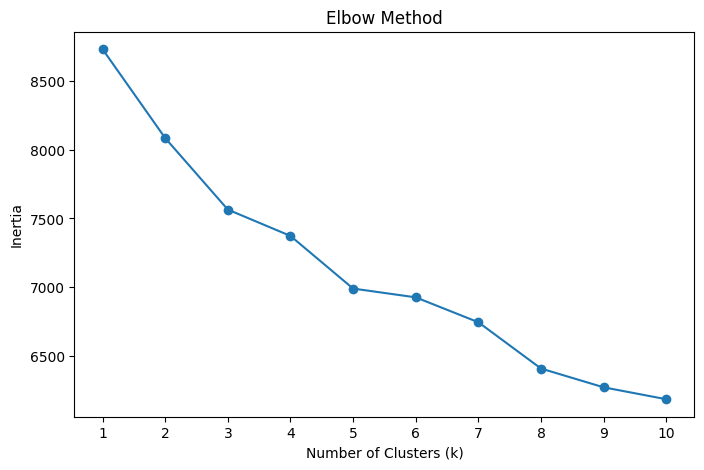

In [168]:
vectorizer = TfidfVectorizer(max_features = 1000, stop_words = "english", min_df = 5)
X = vectorizer.fit_transform(drug_df["warnings"].fillna(""))

k_range = range(1, 11)
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(k_range)
plt.show()

Inertia drops sharply from k=1 to k=2, then declines more gradually and somewhat unevenly through k=6, with a temporary uptick around k=8 — likely because KMeans is only fit once per k here, so it can land in a worse local minimum for some values by chance. We choose **k=4**, since that's roughly where the curve visibly flattens before the later noise, and it's a small enough number of clusters to meaningfully interpret against a known category like `product_type`.

We fit a final KMeans model with k=4, assign each drug to a cluster, and cross-tabulate the clusters against `product_type` to see what percentage of each cluster is OTC, prescription, or cellular therapy.

In [169]:
kmeans = KMeans(n_clusters = 4, random_state = 42)
labels = kmeans.fit_predict(X)

drug_df["cluster"] = labels
pd.crosstab(drug_df["cluster"], drug_df["product_type"], normalize = "index") * 100

product_type,OTC,cellular therapy,prescription
cluster,,,
0,33.252427,0.069348,66.678225
1,99.476097,0.000000,0.523903
2,99.625468,0.000000,0.374532
3,100.000000,0.000000,0.000000


**Summary.** Three of the four clusters are each dominated overwhelmingly by a single product type — Cluster 0 is 100% OTC, Cluster 2 is 93.75% OTC, and Cluster 3 is 99.36% OTC — even though KMeans was never given the `product_type` label and only saw the text of each drug's warnings. Cluster 1 is the exception: a genuine mix of about 42% OTC and 58% prescription drugs. This suggests that OTC and prescription drugs tend to use meaningfully different language in their warning sections (different vocabulary, structure, or severity), distinctive enough that unsupervised clustering on text alone picks up on the split. `cellular therapy` is negligible across all clusters, which just reflects how rare that category is in the dataset overall.

**Data Visualization: Cluster Composition.** 

Each bar represents one of four KMeans clusters. The colored segments show the percentage of drugs in that given cluster that are OTC, prescription, or cellular therapy drugs. This helps show how well the warning text clusters align with known product categories.

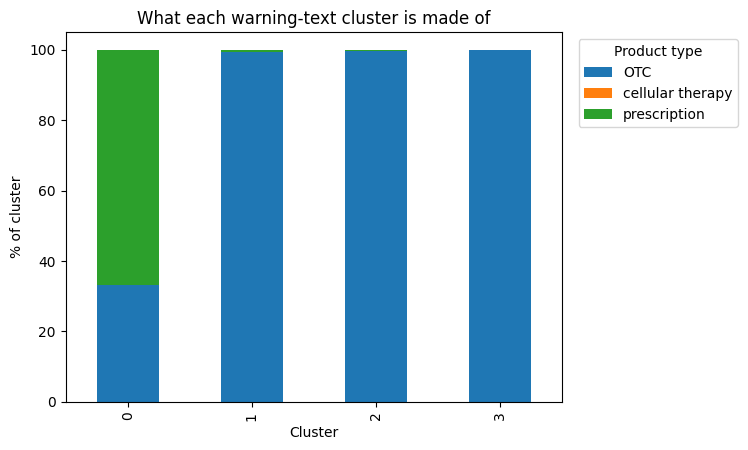

In [170]:
# clusters v.s. product types normalized for summation to 100%
comp = pd.crosstab(drug_df["cluster"], drug_df["product_type"], normalize="index") * 100

ax = comp.plot(kind="bar", stacked=True) # stacks bars instead of side by side

#labels
ax.set_xlabel("Cluster")
ax.set_ylabel("% of cluster")

ax.set_title("What each warning-text cluster is made of")
ax.legend(title="Product type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

**Data Visualization: Defining Terms Per Cluster (TF-IDF).** 

Each bar shows an individual clusters top 10 (weighted) TF-IDF terms present in the warning text.

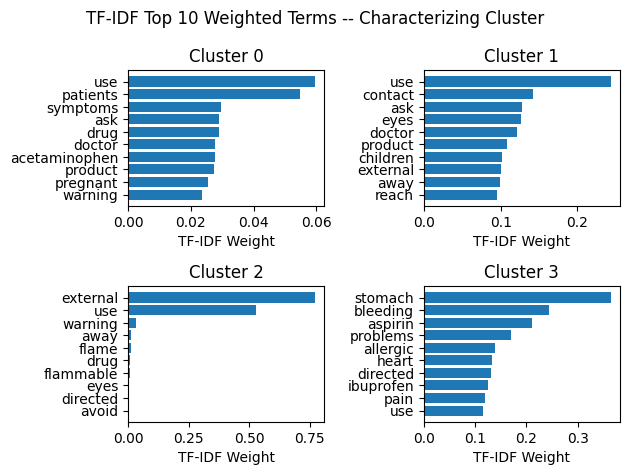

In [171]:
terms = vectorizer.get_feature_names_out() # COLUMN -> o.g. Word
centroids = kmeans.cluster_centers_ # grab clusters, centriods

fig, axes = plt.subplots(2, 2) # 2x2 grid, each cluster gets a window

for i, ax in enumerate(axes.flat):

    # get top 10 biggest terms
    t_10_idx = centroids[i].argsort()[-10::][::-1]
    t_10_terms = terms[t_10_idx] # get actual terms/words
    t_10_weights = centroids[i][t_10_idx] # and centroid weights

    # Plottings
    ax.barh(t_10_terms, t_10_weights) #hori-bars
    ax.invert_yaxis() # bigest @top
    ax.set_title(f"Cluster {i}")
    ax.set_xlabel("TF-IDF Weight")

fig.suptitle("TF-IDF Top 10 Weighted Terms -- Characterizing Cluster")
plt.tight_layout() # was overlapping
plt.show()

## Additional Primary Analysis - Predicting Warning Severity and Pregnancy/Breastfeeding Guidance
### Research Question
Can drug route, do-not use guidance, stop-use guidance, when-using, and adverse-reaction info be used to predict warning length category and whether or not a drug label contains pregnancy or breastfeeding guidance?

To test this question thoroughly, we compare Logistic Regression, Decision Tree, and Random Forest classifiers. Text-based features are represented by their character lengths because this is more reliable from the earlier analysis. Warning lengths are then divided into four categories.
Approach:
  1. Retain the drugs with the most common routes.
  2. To factor in features that do not have a specific format, we will count their length.
  3. We will determine which models perform best for the warning and pregnancy questions, then we will discuss if the best model performs well.

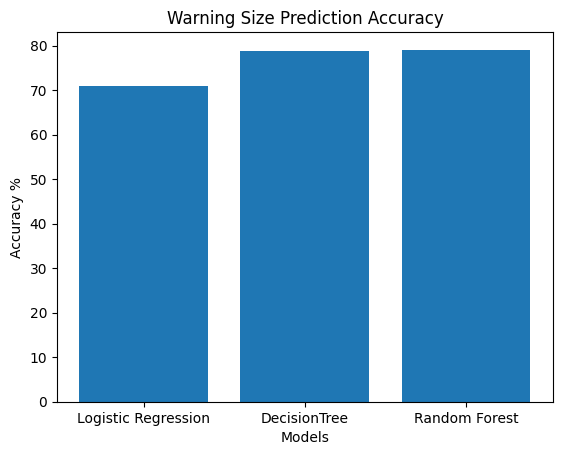

In [172]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score

import matplotlib.pyplot as plt
import matplotlib
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

import ast
pd.set_option('display.max_columns', None)
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go
import plotly.express as px

warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")


from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def countOthers(thing):
  thing = str(thing)
  if (not thing):
    return 0
  return len(thing)

def countUse(thing):
  thing = str(thing)
  if (thing == "use"):
    return 0
  return len(thing)

def warnCat(warning):
  warning = str(warning)
  length = len(warning)
  if length <= mean_warning/2:
    return 1
  elif length <= mean_warning:
    return 2
  elif length <= (3/2) * mean_warning:
    return 3
  elif length > (3/2) * mean_warning:
    return 4

def changePreg(status):
  status = str(status)
  if (status == "Fine"):
    return 1
  if (status == "Bad"):
    return 0

def changeRoute(route):
  route = str(route)
  return mappings.get(route)

route_df2 = drug_df2.copy()
route_df2 = route_df2[route_df2["route"].notna()]
common_routes2 = route_df2["route"].value_counts()
count_before2 = common_routes2.sum()
common_routes2 = common_routes2[common_routes2 >= 100]
count_after2 = common_routes2.sum()

important_routes2 = pd.Series(common_routes2.index)
route_df2 = route_df2[route_df2["route"].isin(important_routes2)]
route_df2 = route_df2[["route", "do_not_use", "stop_use", "when_using", "adverse_reactions", "warnings", "pregnancy_or_breast_feeding"]]
route_df2["pregnancy_or_breast_feeding"] = route_df2["pregnancy_or_breast_feeding"].apply(changePreg)
mappings = {"oral": 0, "topical": 1, "intravenous": 2, "ophthalmic": 3, "dental": 4, "respiratory (inhalation)": 5}
route_df2["do_not_use_length"] = route_df2["do_not_use"].apply(countUse)

route_df2["warnings"] = route_df2["warnings"].fillna("")
mean_warning = route_df2["warnings"].str.len().mean()
route_df2["stop_use"] = route_df2["stop_use"].fillna("")
route_df2["when_using"] = route_df2["when_using"].fillna("")
route_df2["adverse_reactions"] = route_df2["adverse_reactions"].fillna("")

route_df2["warnings_length"] = route_df2["warnings"].apply(warnCat)
route_df2["stop_use_length"] = route_df2["stop_use"].apply(countOthers)
route_df2["when_using_length"] = route_df2["when_using"].apply(countOthers)
route_df2["adverse_reactions_length"] = route_df2["adverse_reactions"].apply(countOthers)

route_df2["route"] = route_df2["route"].apply(changeRoute)

route_df2 = route_df2[["route", "do_not_use_length", "warnings_length", "stop_use_length", "when_using_length", "adverse_reactions_length", "pregnancy_or_breast_feeding"]]
## X1 is to check if we can predict warning length
X1 = route_df2[["route", "do_not_use_length", "stop_use_length", "when_using_length", "adverse_reactions_length", "pregnancy_or_breast_feeding"]]
Y1 = route_df2["warnings_length"]
seed = 42
test_size=0.2

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, Y1, test_size=test_size, random_state=seed)
models = {"Logistic Regression": LogisticRegression(random_state = 42, max_iter=10000), "DecisionTree": DecisionTreeClassifier(random_state=42), "Random Forest": RandomForestClassifier(random_state=42)}
scalar = StandardScaler()
scalar.fit(X1_train)
X1_train_scaled = scalar.transform(X1_train)
X1_test_scaled = scalar.transform(X1_test)
warnAccu = {}

for model_name, model in models.items():
    np.random.seed(42)
    model.fit(X1_train_scaled, y1_train)
    predictions = model.predict(X1_test_scaled)
    accuracy = accuracy_score(y1_test, predictions)
    warnAccu[model_name] = accuracy * 100

plt.bar(warnAccu.keys(), warnAccu.values())
plt.xlabel("Models")
plt.ylabel("Accuracy %")
plt.title("Warning Size Prediction Accuracy")
plt.show()

X2 = route_df2[["warnings_length", "route", "do_not_use_length", "stop_use_length", "when_using_length", "adverse_reactions_length"]]
Y2 = route_df2["pregnancy_or_breast_feeding"]

seed = 42
test_size=0.2

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, Y2, test_size=test_size, random_state=seed)
models2 = {"Logistic Regression": LogisticRegression(random_state = 42, max_iter=10000), "DecisionTree": DecisionTreeClassifier(random_state = 42), "Random Forest": RandomForestClassifier(random_state = 42)}
scalar = StandardScaler()
scalar.fit(X2_train)
X2_train_scaled = scalar.transform(X2_train)
X2_test_scaled = scalar.transform(X2_test)
warnAccu2 = {}

for model_name, model in models2.items():
    np.random.seed(42)
    model.fit(X2_train_scaled, y2_train)
    predictions = model.predict(X2_test_scaled)
    accuracy = accuracy_score(y2_test, predictions)
    warnAccu2[model_name] = accuracy * 100

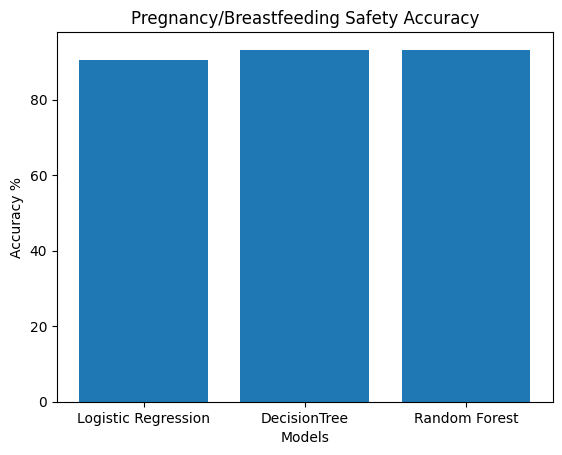

In [173]:
plt.bar(warnAccu2.keys(), warnAccu2.values())
plt.xlabel("Models")
plt.ylabel("Accuracy %")
plt.title("Pregnancy/Breastfeeding Safety Accuracy")
plt.show()

As we can see from both charts, the model is able to make very accurate predictions for which category of size the warning of a drug fits into and if the drug is safe for pregnant/breastfeeding women. This problem appears to be better suited for decision tree based models, with random forest performing the best. Despite this, even the worst performing model, which is logistic regression has a minimum accuracy of 70%+. This indicates two things. Firstly, there is some very strong connection between the features of drug route, do not use, stop use, when using, adverse reactions, and pregnancy or breast feeding and the length of a drug's warning, to the point that the best model can perform in the mid 80s when predicting which category of size the warning fits into. It also tells us that the above features, excluding breast feeding and pregnancy and including warning size also are in some way connected with if a drug is safe for pregnant or breastfeeding women, as every model is able to predict with an 80%+ accuracy. To conclude, we can, with roughly 80% accuracy use the features I mentioned in my initial questions to make predictions about warning sizes and if drugs are safe for pregnant/breastfeeding women.

**Analysis Conclusion** 

In accomplishing our goal of unveiling the intricacies and patterns of FDA drug-label mechanics, across four analyses — market-share dominance, administration route as a proxy for pregnancy and breastfeeding safety, warning-section length as a predictor of longer dosage and administration instructions, and language revealing product category — we discerned that beneath the corporate jargon, the descriptions, labels, and manufacturers provide real but scoped signal.

 1. How Concetrated is the Drug Market?

    This was probably the simplest, and thus most easily scoped — answerable with the given data — question. And the answer: insanely fragmented. Of the roughly 26,000 drug records, 36% carried a manufacturer label. Among those, the single largest maker held less than 5%, the top 5 held less than 12%, and the top 10 just over 17%, whereas nearly half of all manufacturers had just a single product. This is reflected in the Herfindahl-Hirschman Index (HHI), which resolved to roughly 59 — near the complete bottom of the concentration scale. To conceptualize this score, it's roughly equivalent to stating that the drug-label market behaves like 169 equal-sized competitors splitting market share.
    
 2. How does route of administration relate to warning and pregnancy safety?

    We determined the route distribution is heavily right-skewed. Of the six common routes, the vast majority of drugs are oral or topical. We further discerned that these two most common routes — oral and topical — held the two highest warning-severity ratings (analyzed as character length and sentence count), with oral drugs especially, and consistently, having the longest, most severe warnings. However, there was no shortage of oddities: intravenous and respiratory routes — which one would expect to rank higher — had a median warning near zero but a high average, indicating a likely small subset that carries truly the most severe warnings.
    
 3. Do drugs with longer warnings have longer dosage instructions?
Weakly, yes — drugs with longer warnings have longer dosage instructions. The Pearson correlation resolved to 0.244, a weak positive relationship indicating that, generally, the longer the warning the longer the dosage instruction. But the spread is wide, and many points stack substantial residuals off the line of best fit, so we'd be hesitant to declare warning length a valid indicator.

 4. Can warning language alone reveal a drug's product category?
On whether warning verbiage reveals product category, we received mixed results. It was far from spectacular at distinguishing OTC from prescription, but it revealed another helpful fact: the dataset is overwhelmingly OTC, with three of the four clusters — 0, 2, and 3 — coming out to ~94%+ OTC. Circling back to distinguishing prescription drugs, the model was capable of concentrating them into a single cluster — cluster 1, labeled ~50% prescription — but couldn't accurately isolate the majority, instead splitting roughly 50-50 between prescription and OTC.

5. Can other label features predict warning-length category and pregnancy/breastfeeding guidance?
The supervised models showed that route and the lengths of several label sections contain useful predictive information. Random Forest produced the strongest results, while Logistic Regression performed the weakest of the three models. However, accuracy alone may be influenced by uneven class distributions, so these results should be interpreted as evidence of association rather than proof that the models generalize equally well to every warning or pregnancy-guidance category.
